# Pipeline C — Cross-attention BEV fusion

`BEV_camera` (stereo-splat) + `BEV_lidar` (PointPillars) →
**windowed cross-attention + near/far gate** → CenterPoint head.

Drop-in swap of the fusion block vs. Pipeline A (same branches, same head):

| step | module | role |
|------|--------|------|
| 1 | `cam_proj` / `lid_proj` | 1×1 conv → shared embedding E |
| 2 | `_WindowCrossAttention` | camera tokens query LiDAR within 8×8 windows |
| 3 | `gate` | per-cell σ; near cells (g≈0)→stereo, far (g≈1)→LiDAR attn |
| 4 | `post_conv` | local spatial context (mirrors A's conv stack) |

Each section **calls the project `.py` modules** — no heavy code lives here.
Stages not yet built (`train.py`, `evaluation.py`) are left empty as TODO.

## 1. Imports

In [1]:
import numpy as np
import torch

# Project modules — the implementation stays inside the .py files (6-file layout:
# data / evaluation / globals / network / train / utils).
import data, utils
import globals as G                       # shared BEV grid + channel contract (single source)
from data import Py123dDataset
from network import (
    PillarConfig, PointPillarsBranch, StereoBEVBranch,  # Stage A branches
    CrossAttentionFusion, BEVDetector, BEVFusionConfig, # fusion + head
    PipelineC,                                           # end-to-end convenience class
    describe,
)

# Stages still to implement — imported as placeholders.
import train        # noqa: F401  (empty: training loop TODO)
import evaluation   # noqa: F401  (empty: AV2 distance-AP / CDS eval TODO)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

/home/vittorio/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/vittorio/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


device: cuda


/home/vittorio/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Globals

In [2]:
# globals.py is the single source of truth for the shared BEV grid + channel
# contract. Every branch config (PillarConfig, MonoBEVConfig, StereoBEVConfig)
# defaults to it, so the grid can't drift between branches. Indexing: ix*ny+iy.
print("grid_size (nx, ny):", G.GRID_SIZE, "| x_range:", G.X_RANGE, "| y_range:", G.Y_RANGE)
print("channels — camera:", G.CAMERA_BEV_CHANNELS, "| lidar:", G.LIDAR_BEV_CHANNELS,
      "| fused:", G.FUSED_CHANNELS, "| num_classes:", G.NUM_CLASSES)

# Pipeline C attention hyper-params (can override in CrossAttentionFusion constructor).
WIN_H, WIN_W = 8, 8   # window size; n = 64 tokens/window on the 200×160 grid
NUM_HEADS    = 4       # must divide G.FUSED_CHANNELS
print(f"cross-attention: win={WIN_H}×{WIN_W}, heads={NUM_HEADS}, "
      f"tokens/window={WIN_H*WIN_W}")

grid_size (nx, ny): (200, 160) | x_range: (0.0, 50.0) | y_range: (-20.0, 20.0)
channels — camera: 64 | lidar: 128 | fused: 128 | num_classes: 3
cross-attention: win=8×8, heads=4, tokens/window=64


## 3. Utils

In [3]:
# Visualisation helpers live in utils.py (LiDAR density BEV + GT boxes, point
# cloud, stereo pair, frustum, voxels, clusters, pipeline debug maps).
import utils
print([f for f in dir(utils) if f.startswith("visualize_")])
# e.g. utils.visualize_bev(sample)              -> ego-frame boxes over a LiDAR BEV
#      utils.visualize_pipeline_debug(pipeline) -> per-stage BEV maps (requires debug=True)

['visualize_attention_gate', 'visualize_bev', 'visualize_clusters', 'visualize_encoded_targets', 'visualize_frustum', 'visualize_images', 'visualize_pipeline_debug', 'visualize_pointcloud', 'visualize_voxels']


## 4. Data

In [4]:
# data.py loads Argoverse 2 through py123d and assembles one StereoSample / frame.
dataset = Py123dDataset(split_names=["av2-sensor_val"], max_num_scenes=1)
frame   = dataset.get_frame(0, dataset.scenes[0].number_of_history_iterations + 13)
sample  = frame.to_stereo_sample()
print(sample)

# GT boxes: global frame (for 2D projection) + ego frame (for BEV target encoding).
# See data.boxes_global_to_ego / assert_boxes_in_sensor_range.
print("boxes_3d (global):", sample.boxes_3d.shape,
      "| boxes_3d_ego:", sample.boxes_3d_ego.shape)
# utils.visualize_images(sample); utils.visualize_pointcloud(sample)

DEBUG: PY123D_DATA_ROOT resolved to /home/vittorio/datasets/av2
DEBUG: found 1 scenes using filter SceneFilter(datasets=None, split_types=None, split_names=['av2-sensor_val'], log_names=None, has_map=None, map_has_z=None, map_locations=None, map_version=None, log_locations=None, log_version=None, scene_uuids=None, target_iteration_duration_s=None, future_duration_s=None, history_duration_s=None, timestamp_threshold_s=None, target_iteration_stride=None, future_num_iterations=None, history_num_iterations=None, iteration_threshold=None, required_scene_modalities=None, custom_filter_fns=None, num_chunks=None, chunk_idx=None, max_num_scenes=1, shuffle=False)
StereoSample(dataset='av2-sensor', log='02678d04-cc9f-3148-9f95-1ba66347dff9', iter=13, boxes_3d=27, boxes_2d=7, lidar_pts=93509, depth=no)
boxes_3d (global): (27, 10) | boxes_3d_ego: (27, 10)


## 5. Network

### 5a. Stage A — BEV branches (identical to Pipelines A / B)

In [5]:
# --- Stage A: the two BEV branches emit grid-aligned (C, nx, ny) maps ----------
lidar_branch  = PointPillarsBranch(PillarConfig()).to(DEVICE).eval()
camera_branch = StereoBEVBranch().to(DEVICE).eval()

# PointPillars wants (N, 4) = [x, y, z, intensity], so append the reflectance.
pts_lidar = np.concatenate(
    [sample.lidar_xyz, sample.lidar_features["intensity"][:, None]], axis=1
).astype(np.float32)

with torch.no_grad():
    bev_lidar  = lidar_branch(pts_lidar, device=DEVICE)   # (C_lidar, nx, ny)
    bev_camera = camera_branch(sample, device=DEVICE)      # (C_cam,   nx, ny)

print("BEV_lidar:", tuple(bev_lidar.shape), "| BEV_camera:", tuple(bev_camera.shape))

BEV_lidar: (128, 200, 160) | BEV_camera: (64, 200, 160)


### 5b. Stage 4 — CrossAttentionFusion + CenterPoint head

In [6]:
# Build the Pipeline-C detector: same BEVDetector API as A, but with
# fusion_cls=CrossAttentionFusion. from_bev_maps reads the channel contract
# straight off the Stage A tensors — the grid can't drift between runs.
detector = BEVDetector.from_bev_maps(
    bev_camera, bev_lidar,
    num_classes=3,
    fusion_cls=CrossAttentionFusion,          # <-- the only change vs Pipeline A
).to(DEVICE).eval()

describe(detector)   # prints channel contract + parameter counts

with torch.no_grad():
    out = detector(bev_camera, bev_lidar)

print({k: tuple(v.shape) for k, v in out.items()})
#   heatmap (1, num_classes, nx, ny)  +  offset (1, 2, nx, ny)

# TODO (target encoder): rasterize sample.boxes_3d_ego[:, :2] + class into the
#   same (num_classes, nx, ny) heatmap + (2, nx, ny) offset targets to train against.

BEV fusion contract — Stage A must emit, on the shared grid:
  camera BEV : (B, 64, 200, 160)
  lidar  BEV : (B, 128, 200, 160)
  fused      : (B, 128, 200, 160)
  head out   : heatmap (B, 3, 200, 160) + offset (B, 2, 200, 160)
parameters:
  fusion : 420,613
  head   : 74,181
  total  : 494,794
{'heatmap': (1, 3, 200, 160), 'offset': (1, 2, 200, 160)}


### 5c. End-to-end convenience — PipelineC

`PipelineC` wraps both branches + the cross-attention detector in one module:
`pipeline(sample, device)` → `{heatmap, offset}`.  
Enable `debug=True` to capture BEV maps at every stage.

In [7]:
# PipelineC sets fusion_cls = CrossAttentionFusion at the class level.
# Identical interface to PipelineA — only the fusion internals differ.
pipeline = PipelineC(num_classes=3).to(DEVICE)
pipeline.debug = True   # store intermediates after forward

with torch.no_grad():
    out_pipe = pipeline(sample, device=DEVICE)

print({k: tuple(v.shape) for k, v in out_pipe.items()})

# Intermediates: bev_camera, bev_lidar, fused, heatmap, offset — all (C, nx, ny).
print("intermediates:", {k: tuple(v.shape) for k, v in pipeline.intermediates.items()})

# Full pipeline debug panels (requires matplotlib):
# utils.visualize_pipeline_debug(pipeline)

{'heatmap': (1, 3, 200, 160), 'offset': (1, 2, 200, 160)}
intermediates: {'bev_camera': (64, 200, 160), 'bev_lidar': (128, 200, 160), 'fused': (128, 200, 160), 'heatmap': (3, 200, 160), 'offset': (2, 200, 160)}


### 5d. Attention gate visualisation

The gate map `g ∈ (0, 1)` is a per-cell scalar produced by a lightweight 1×1 conv
on `cat(cam_proj, lid_proj)`.  Near cells (dense stereo) converge to **g ≈ 0**
(trust camera); far cells (sparse stereo, reliable LiDAR beams) converge to
**g ≈ 1** (trust LiDAR attention).  Plot it to verify the model learns the
expected near/far geometry.

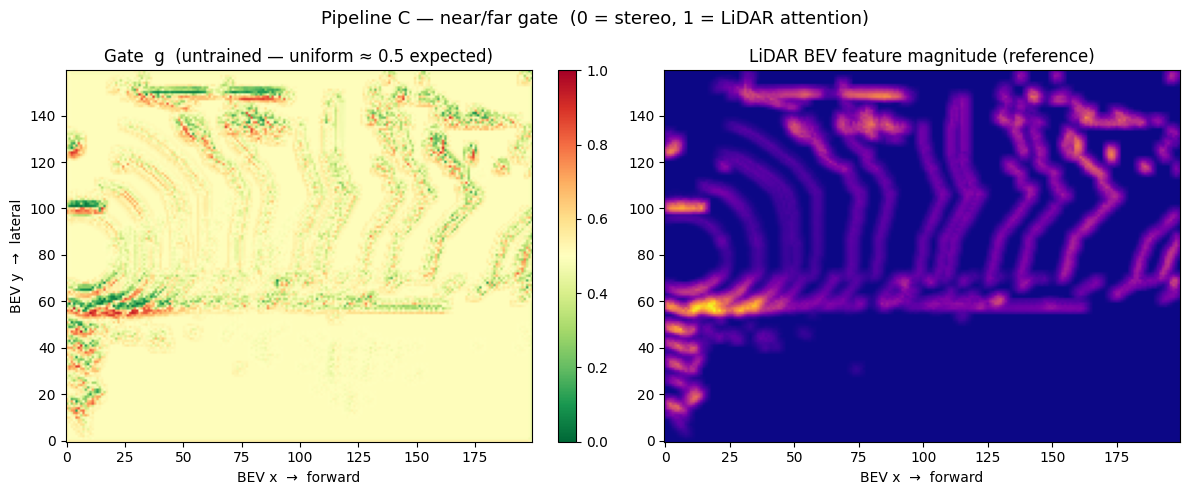

gate stats — min: 0.0138  max: 0.9668  mean: 0.5008


In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Extract the gate map directly from the CrossAttentionFusion internals ----
# We run a partial forward (cam_proj + lid_proj + gate) to get g without the
# full attention pass — useful for quick ablations or visual sanity checks.
fusion = pipeline.detector.fusion   # CrossAttentionFusion instance

bev_cam_b = bev_camera.unsqueeze(0).to(DEVICE)   # add batch dim
bev_lid_b = bev_lidar.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    cam_e = fusion.cam_proj(bev_cam_b)                          # (1, E, nx, ny)
    lid_e = fusion.lid_proj(bev_lid_b)                          # (1, E, nx, ny)
    gate  = fusion.gate(torch.cat([cam_e, lid_e], dim=1))       # (1, 1, nx, ny)

gate_np = gate[0, 0].cpu().numpy()   # (nx, ny)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Pipeline C — near/far gate  (0 = stereo, 1 = LiDAR attention)",
             fontsize=13)

# Gate map
im = axes[0].imshow(
    gate_np.T, origin="lower", cmap="RdYlGn_r",
    vmin=0, vmax=1, aspect="auto",
)
axes[0].set_title("Gate  g  (untrained — uniform ≈ 0.5 expected)")
axes[0].set_xlabel("BEV x  →  forward")
axes[0].set_ylabel("BEV y  →  lateral")
plt.colorbar(im, ax=axes[0], fraction=0.046)

# LiDAR density BEV for spatial reference
lid_density = bev_lidar.cpu().norm(dim=0).numpy()   # crude per-cell magnitude
axes[1].imshow(lid_density.T, origin="lower", cmap="plasma", aspect="auto")
axes[1].set_title("LiDAR BEV feature magnitude (reference)")
axes[1].set_xlabel("BEV x  →  forward")

plt.tight_layout()
plt.show()

print(f"gate stats — min: {gate_np.min():.4f}  max: {gate_np.max():.4f}"
      f"  mean: {gate_np.mean():.4f}")

### 5e. Pipeline A vs C — fused BEV comparison

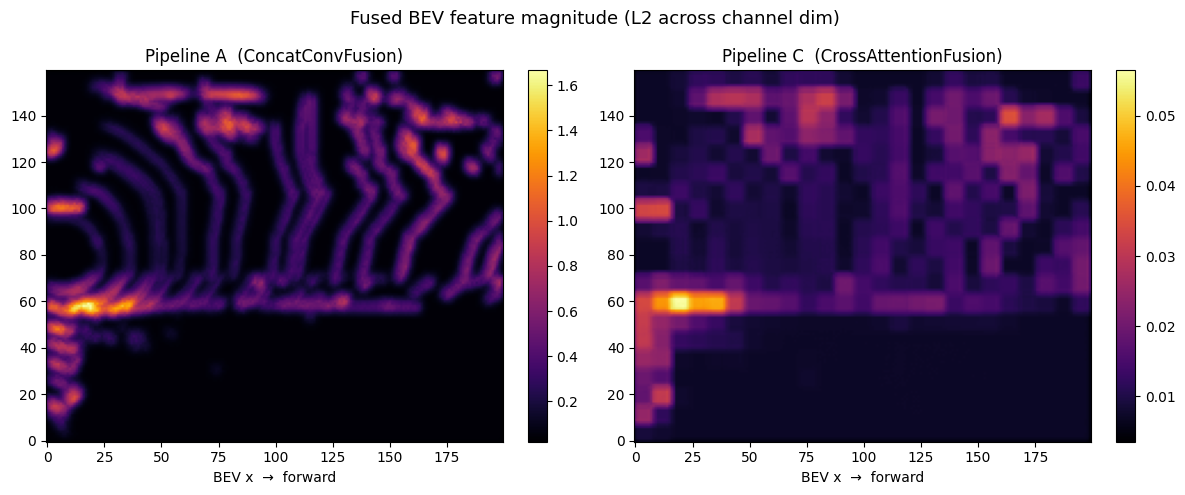

In [10]:
from network import ConcatConvFusion

# Build Pipeline A detector (same channel contract, concat+conv fusion).
detector_a = BEVDetector.from_bev_maps(
    bev_camera, bev_lidar, num_classes=3,
    fusion_cls=ConcatConvFusion,
).to(DEVICE).eval()

with torch.no_grad():
    fused_a = detector_a.fusion(bev_camera, bev_lidar)[0].cpu()   # (E, nx, ny)
    fused_c = detector.fusion(bev_camera, bev_lidar)[0].cpu()     # (E, nx, ny)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Fused BEV feature magnitude (L2 across channel dim)", fontsize=13)

for ax, feat, title in zip(
    axes,
    [fused_a, fused_c],
    ["Pipeline A  (ConcatConvFusion)", "Pipeline C  (CrossAttentionFusion)"],
):
    mag = feat.norm(dim=0).numpy()
    im  = ax.imshow(mag.T, origin="lower", cmap="inferno", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("BEV x  →  forward")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

## 6. Train

In [ ]:
# TODO: train.py is empty.


## 7. Test

In [ ]:
# TODO: evaluation.py is empty.
